### IMPORTS

In [13]:
import pandas as pd
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### SPLITTING INTO TRAIN AND TEST DATA

In [14]:
df = pd.read_csv('abalone.csv')
colNames = list(df.columns)
X_train, X_test, y_train, y_test = train_test_split(df.drop('Rings', axis=1), df['Rings'], test_size=0.3, random_state=42)
trainData = pd.concat([X_train, y_train], axis=1)
testData = pd.concat([X_test, y_test], axis=1)
trainData.columns = testData.columns = colNames
trainData.index = range(len(trainData))
testData.index = range(len(testData))
trainData.to_csv('abalone_train.csv', index = False)
testData.to_csv('abalone_test.csv', index = False)

### FINDING THE ATTRIBUTE

In [15]:
def getPearsonCorrCoeff(feature, target):
    feature = np.array(feature)
    target = np.array(target)
    featureMean = np.mean(feature)
    targetMean = np.mean(target)
    featureStd = np.std(feature)
    targetStd = np.std(target)
    num = np.sum((feature - featureMean) * (target - targetMean))
    den = len(feature) * featureStd * targetStd
    return num / den

In [16]:
attr = ''
prevVal = -1
colNames.pop()
for col in colNames:
    val = getPearsonCorrCoeff(df[col], df['Rings'])
    if (val > prevVal):
        prevVal = val
        attr = col 
print(f'The Attribute with highest correlation with Rings is {attr}')     

The Attribute with highest correlation with Rings is Shell weight


### SIMPLE LINEAR REGRESSION

In [17]:
class LinearRegression:

    def __init__(self):
        self.coef = None
        self.intercept = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        xMean = np.mean(X)
        yMean = np.mean(y)
        self.coef = np.sum((X - xMean) * (y - yMean)) / np.sum((X - xMean) ** 2)
        self.intercept = yMean - self.coef * xMean

    def predict(self, X):
        return self.coef*X + self.intercept
    
    def rmse(self, y, yPred):
        return np.sqrt(np.sum((y - yPred) ** 2) / len(y))

In [18]:
xTrain = trainData[attr].values.reshape(-1, 1)
yTrain = trainData['Rings'].values.reshape(-1, 1)
xTest = testData[attr].values.reshape(-1, 1)
yTest = testData['Rings'].values.reshape(-1, 1)
lr = LinearRegression()
lr.fit(xTrain, yTrain)
yTrainPred = lr.predict(xTrain)
yTestPred = lr.predict(xTest)

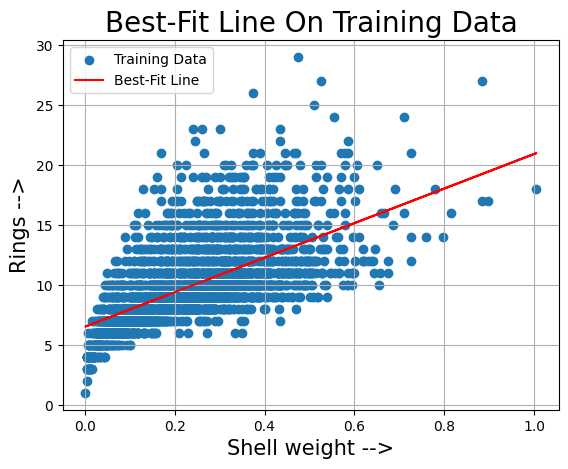

Prediction accuracy on training data: 2.527846339134725
Prediction accuracy on testing data: 2.467940147010543


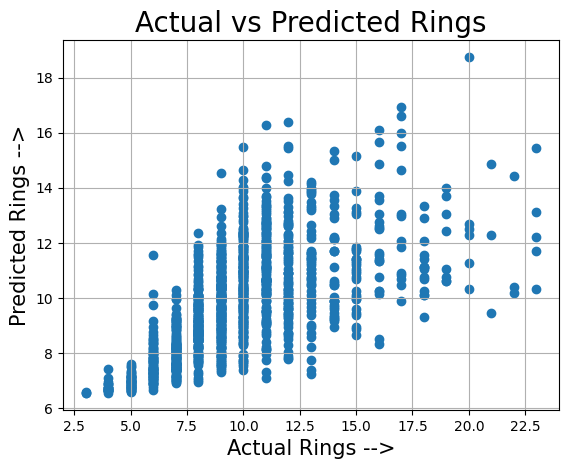

In [19]:
plt.scatter(xTrain, yTrain, label = 'Training Data')
plt.plot(xTrain, yTrainPred, color = 'red', label = 'Best-Fit Line')
plt.xlabel(f'{attr} -->', fontsize = 15)
plt.ylabel('Rings -->', fontsize = 15)
plt.legend()
plt.title('Best-Fit Line On Training Data', fontsize = 20)
plt.grid()
plt.show()

print(f'Prediction accuracy on training data: {lr.rmse(yTrain, yTrainPred)}')
print(f'Prediction accuracy on testing data: {lr.rmse(yTest, yTestPred)}')

plt.scatter(yTest, yTestPred)
plt.xlabel('Actual Rings -->', fontsize = 15)
plt.ylabel('Predicted Rings -->', fontsize = 15)
plt.title('Actual vs Predicted Rings', fontsize = 20)
plt.grid()
plt.show()

### SIMPLE NONLINEAR REGRESSION

In [20]:
class PolynomialRegression:

    def __init__(self, degree):
        self.degree = degree
        self.weights = None

    def __transform(self, X):
        X = np.array(X)
        XTransformed = np.ones(shape = (X.shape[0], 1))
        for i in range(1, self.degree + 1):
            XTransformed = np.hstack((XTransformed, X**i))
        return XTransformed
    
    def fit(self, X, y):
        X = self.__transform(X)
        daggerX = np.dot(la.inv(np.dot(X.T, X)), X.T)
        self.weights = np.dot(daggerX, y)

    def predict(self, X):
        X = self.__transform(X)
        return np.dot(X, self.weights)
    
    def rmse(self, y, yPred):
        return np.sqrt(np.sum((y - yPred)**2) / len(y))

In [21]:
degrees = np.arange(2, 13)
yTrainPredArr = np.empty(shape = (len(yTrain), 0))
yTestPredArr = np.empty(shape = (len(yTest), 0))
yTrainAcc = np.empty(shape = (0, 0))
yTestAcc = np.empty(shape = (0, 0))

for p in degrees:
    pr = PolynomialRegression(p)
    pr.fit(xTrain, yTrain)
    yTrainPred = pr.predict(xTrain)
    yTestPred = pr.predict(xTest)
    yTrainPredArr = np.hstack((yTrainPredArr, yTrainPred))
    yTestPredArr = np.hstack((yTestPredArr, yTestPred))
    yTrainAcc = np.append(yTrainAcc, pr.rmse(yTrain, yTrainPred))
    yTestAcc = np.append(yTestAcc, pr.rmse(yTest, yTestPred))

bestPoly = np.argmin(yTrainAcc)
# yTrainAcc

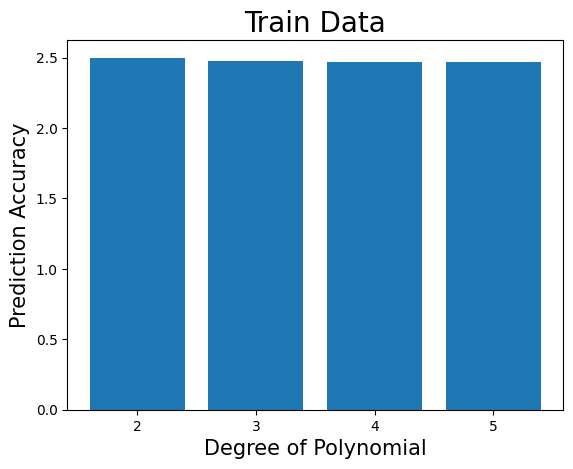

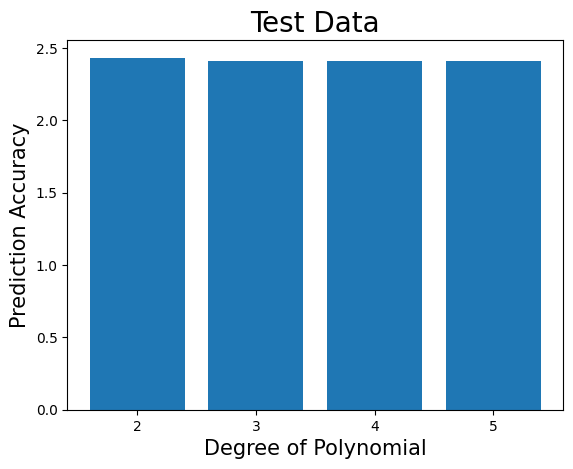

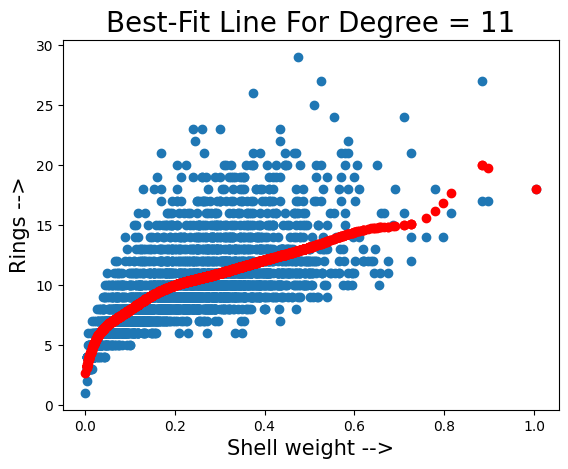

In [22]:
plt.bar(degrees[: 4], yTrainAcc[: 4])
plt.xlabel('Degree of Polynomial', fontsize = 15)
plt.ylabel('Prediction Accuracy', fontsize = 15)
plt.title('Train Data', fontsize = 20)
plt.xticks(degrees[: 4])
plt.show()

plt.bar(degrees[: 4], yTestAcc[: 4])
plt.xlabel('Degree of Polynomial', fontsize = 15)
plt.ylabel('Prediction Accuracy', fontsize = 15)
plt.title('Test Data', fontsize = 20)
plt.xticks(degrees[: 4])
plt.show()

plt.scatter(xTrain, yTrain, label = 'Training Data')
plt.scatter(xTrain, yTrainPredArr[:, bestPoly], color = 'red', label = 'Best-Fit Line')
plt.xlabel(f'{attr} -->', fontsize = 15)
plt.ylabel('Rings -->', fontsize = 15)
plt.title(f'Best-Fit Line For Degree = {degrees[bestPoly]}', fontsize = 20)
plt.show()